# Bone marrow integration with regularizedvi

This tutorial demonstrates how to use **regularizedvi** (`AmbientRegularizedSCVI`) for single-cell RNA-seq integration, using the NeurIPS 2021 bone marrow multiome dataset (69k cells, 13 batches, 4 sites, 10 donors).

The key idea is to adapt [cell2location](https://doi.org/10.1038/s41587-021-01139-4)/[cell2fate](https://doi.org/10.1038/s41592-025-02608-3) modelling principles to scVI:

1. **Ambient RNA correction** — per-gene, per-batch additive background captures ambient RNA contamination
2. **Dispersion regularisation** — Exponential containment prior on dispersion
3. **Batch-free decoder** — separating constrained additive (ambient) from flexible multiplicative (categorical covariates) correction
4. **Learned library size** — with constrained prior (observed totals include ambient RNA)

See [model_comparisons/](model_comparisons/) for systematic comparisons with standard scVI variants.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy
import torch

import scvi
import regularizedvi

# Simple text progress bar (works with papermill)
scvi.settings.progress_bar_style = "tqdm"

# Use high-precision matmul for better numerical stability on GPU
torch.set_float32_matmul_precision("high")

rcParams["pdf.fonttype"] = 42  # enables correct plotting of text for publication figures

## 1. Load data

Load the bone marrow multiome dataset and extract the GEX (gene expression) modality.

In [2]:
import os

from regularizedvi.utils import download_bone_marrow_dataset

results_folder = "results/regularizedvi_tutorial/"
os.makedirs(results_folder, exist_ok=True)

h5ad_path = download_bone_marrow_dataset(data_folder="data/")
adata = sc.read_h5ad(h5ad_path)

# Extract gene expression only
adata = adata[:, adata.var["feature_types"] == "GEX"].copy()
adata.var["SYMBOL"] = adata.var_names.values.copy()
adata.var_names = adata.var["gene_ids"].values.astype(str).copy()
adata.X = adata.layers["counts"]

print(adata)
print(f"\nBatches: {adata.obs['batch'].nunique()}")
print(f"Sites: {adata.obs['site'].nunique()}")
print(f"Donors: {adata.obs['donor'].nunique()}")

Found data/bmmc_multiome_multivi_neurips21_curated.h5ad


AnnData object with n_obs × n_vars = 69247 × 25629
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'GEX_pseudotime_order', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_pseudotime_order', 'DonorID', 'VendorLot', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'modality', 'site', 'donor', 'batch', 'l1_cell_type', 'l2_cell_type', 'neurips21_cell_type', 'old_neurips21_obs_names', 'frag_file_bcs'
    var: 'gene_ids', 'feature_types', 'hvg_multiVI', 'SYMBOL'
    uns: 'ATAC_gene_activity_var_names', '_scvi', 'dataset_id', 'genome', 'neighbors', 'organism', 'umap'
    obsm: 'ATAC_gene_activity', 'MultiVI_latent', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

Batches: 13
Sites: 4
Donors: 10


## 2. Quality control

In [3]:
# Batch and cell type composition
for c in ["batch", "site", "donor", "l2_cell_type"]:
    print(adata.obs[c].value_counts())
    print()

batch
s4d8     9876
s4d1     8023
s3d10    6780
s1d2     6740
s1d1     6224
s2d4     6111
s2d5     4895
s3d3     4325
s4d9     4325
s1d3     4279
s2d1     4220
s3d7     1770
s3d6     1679
Name: count, dtype: int64

site
site4    22224
site1    17243
site2    15226
site3    14554
Name: count, dtype: int64

donor
donor1     18467
donor8      9876
donor3      8604
donor10     6780
donor2      6740
donor4      6111
donor5      4895
donor9      4325
donor7      1770
donor6      1679
Name: count, dtype: int64

l2_cell_type
CD8+ T activated    11589
CD14+ Mono          10842
NK                   6929
CD4+ T activated     5526
Naive CD20+ B        5052
Erythroblast         4916
CD4+ T naive         4398
Transitional B       2810
Proerythroblast      2300
CD16+ Mono           1894
B1 B                 1890
Normoblast           1780
Early Lymphoid       1779
G/M prog             1203
pDC                  1191
HSC                  1072
CD8+ T naive         1012
MK/E prog             884
cDC2     

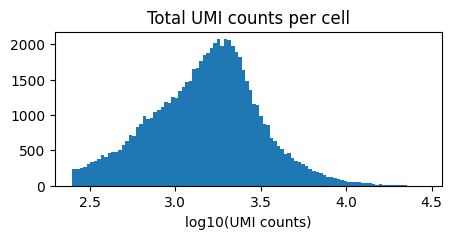

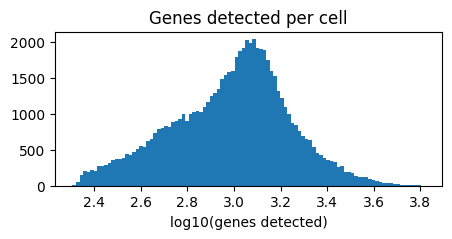

In [4]:
# QC distributions
rcParams["figure.figsize"] = 5, 2
plt.hist(np.log10(adata.obs["GEX_n_counts"]), bins=100)
plt.xlabel("log10(UMI counts)")
plt.title("Total UMI counts per cell")
plt.show()

plt.hist(np.log10(adata.obs["GEX_n_genes"]), bins=100)
plt.xlabel("log10(genes detected)")
plt.title("Genes detected per cell")
plt.show()

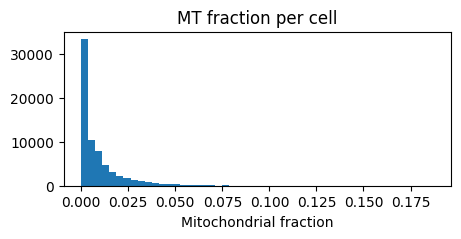

In [5]:
# Mitochondrial fraction
adata.var["mt"] = [gene.startswith("MT-") for gene in adata.var["SYMBOL"]]
adata.obs["mt_frac"] = adata[:, adata.var["mt"].tolist()].X.sum(1).A.squeeze() / adata.obs["GEX_n_counts"]

plt.hist(adata.obs["mt_frac"], bins=50)
plt.xlabel("Mitochondrial fraction")
plt.title("MT fraction per cell")
plt.show()

### Gene selection for QC

Select informative genes using `regularizedvi.utils.filter_genes` (adapted from cell2location). These genes are used for doublet detection below; the actual subsetting of `adata` happens after cell filtering.

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


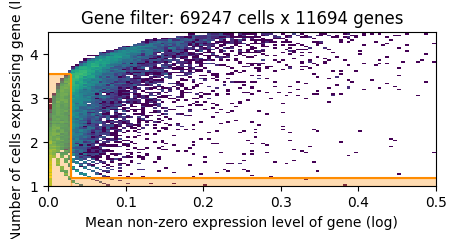

In [6]:
from regularizedvi.utils import filter_genes

selected = filter_genes(
    adata,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.05,
    nonz_mean_cutoff=1.07,
)

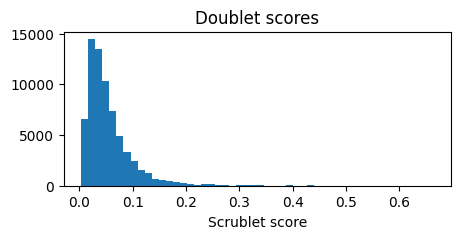

Fraction above 0.18 threshold: 0.025


In [7]:
adata_for_scrublet = adata[:, selected].copy()
sc.pp.scrublet(
    adata_for_scrublet,
    batch_key="batch",
    n_prin_comps=40,
    verbose=False,
)
adata.obs["doublet_score"] = adata_for_scrublet.obs["doublet_score"]
adata.obs["predicted_doublet"] = adata_for_scrublet.obs["predicted_doublet"]
del adata_for_scrublet

plt.hist(adata.obs["doublet_score"], bins=50)
plt.xlabel("Scrublet score")
plt.title("Doublet scores")
plt.show()

print(f"Fraction above 0.18 threshold: {(adata.obs['doublet_score'] > 0.18).mean():.3f}")

In [8]:
# Cell filtering
n_before = adata.n_obs
adata = adata[
    (adata.obs["GEX_n_genes"] > 500)
    & (adata.obs["GEX_n_counts"] > 1000)
    & (adata.obs["GEX_n_counts"] < 80000)
    & (adata.obs["GEX_n_genes"] < 10000)
    & (adata.obs["ATAC_atac_fragments"] > 1000)
    & (adata.obs["ATAC_atac_fragments"] < 100000)
    & (adata.obs["mt_frac"] < 0.20)
    & (adata.obs["doublet_score"] < 0.18),
    :,
]
print(f"Filtered {n_before} → {adata.n_obs} cells ({n_before - adata.n_obs} removed)")

Filtered 69247 → 46534 cells (22713 removed)


## 3. Gene filtering

Recompute gene selection on the filtered cells — cell composition affects detection rates, so we re-run `filter_genes` after QC filtering.

/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/src/regularizedvi/utils/_filtering.py:30: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = np.array((adata.X > 0).sum(0)).flatten()


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


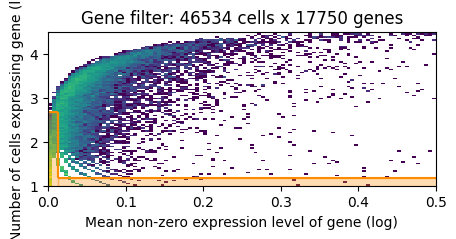

Selected 17750 genes


In [9]:
selected = filter_genes(
    adata,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.01,
    nonz_mean_cutoff=1.03,
)
adata = adata[:, selected].copy()

print(f"Selected {adata.n_vars} genes")

## 4. Model setup and training

### Setup anndata

- `batch_key='batch'` — identifies biological samples. Each sample gets its own ambient RNA background ($b_{g,s}$) and overdispersion ($\theta_{g,s}$).
- `categorical_covariate_keys=['site', 'donor']` — known technical/biological covariates modelled as multiplicative effects (like $p_{tg}$ in cell2location). These handle systematic differences between processing sites and donors.

In [10]:
adata.layers["counts"] = adata.X

regularizedvi.AmbientRegularizedSCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="batch",
    categorical_covariate_keys=["site", "donor"],
)

### Create model

Same architecture as the default regularizedvi tutorial, but with `likelihood_distribution="gamma_poisson"` — uses Pyro's GammaPoisson likelihood and the cell2location-style dispersion prior (Exp on $1/\sqrt{\theta}$, pushing $\theta$ large toward Poisson).

In [11]:
model = regularizedvi.AmbientRegularizedSCVI(
    adata,
    n_hidden=512,
    n_layers=1,
    n_latent=128,
    likelihood_distribution="gamma_poisson",
)

### Train

- **`train_size=1.0`** — use all data for training. With regularised dispersion and additive background, the model is less prone to overfitting.
- **`max_epochs=2000`** — longer training for convergence. The model has more parameters (additive background, learned library size) that need sufficient epochs.
- **`batch_size=1024`** — large batches for stable gradient estimates, especially important for the per-batch additive background parameters.

In [12]:
model.train(
    train_size=1.0,
    max_epochs=2000,
    batch_size=1024,
)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2000` reached.


### Training loss

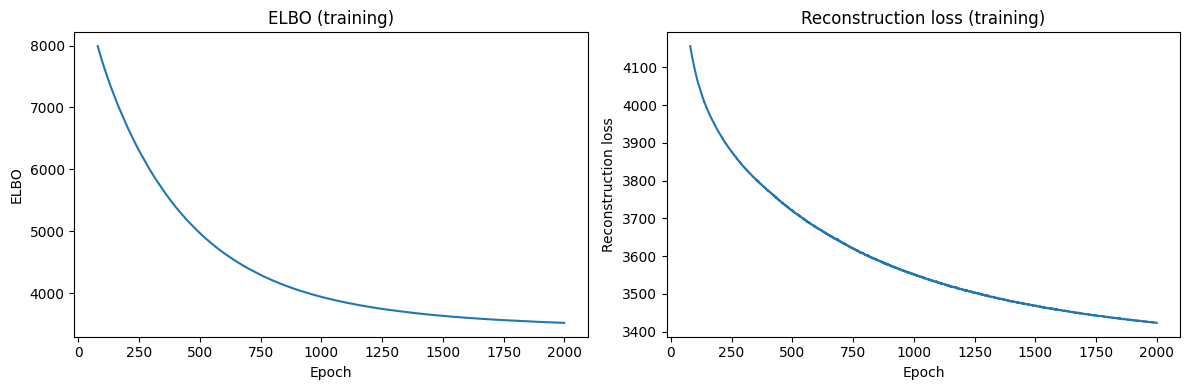

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(model.history_["elbo_train"][80:])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO")
axes[0].set_title("ELBO (training)")

axes[1].plot(model.history_["reconstruction_loss_train"][80:])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Reconstruction loss")
axes[1].set_title("Reconstruction loss (training)")

plt.tight_layout()
plt.show()

### Save model

In [14]:
ref_run_name = f"{results_folder}/model"

model.save(ref_run_name, overwrite=True)

## 5. Latent space and visualisation

In [15]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent

print(f"Latent representation shape: {latent.shape}")

Latent representation shape: (46534, 128)


In [16]:
# Compute KNN and UMAP
k = 50
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=k, metric="euclidean")
sc.tl.umap(adata, min_dist=0.4, spread=1.3)
sc.tl.leiden(adata, resolution=12, flavor="igraph")

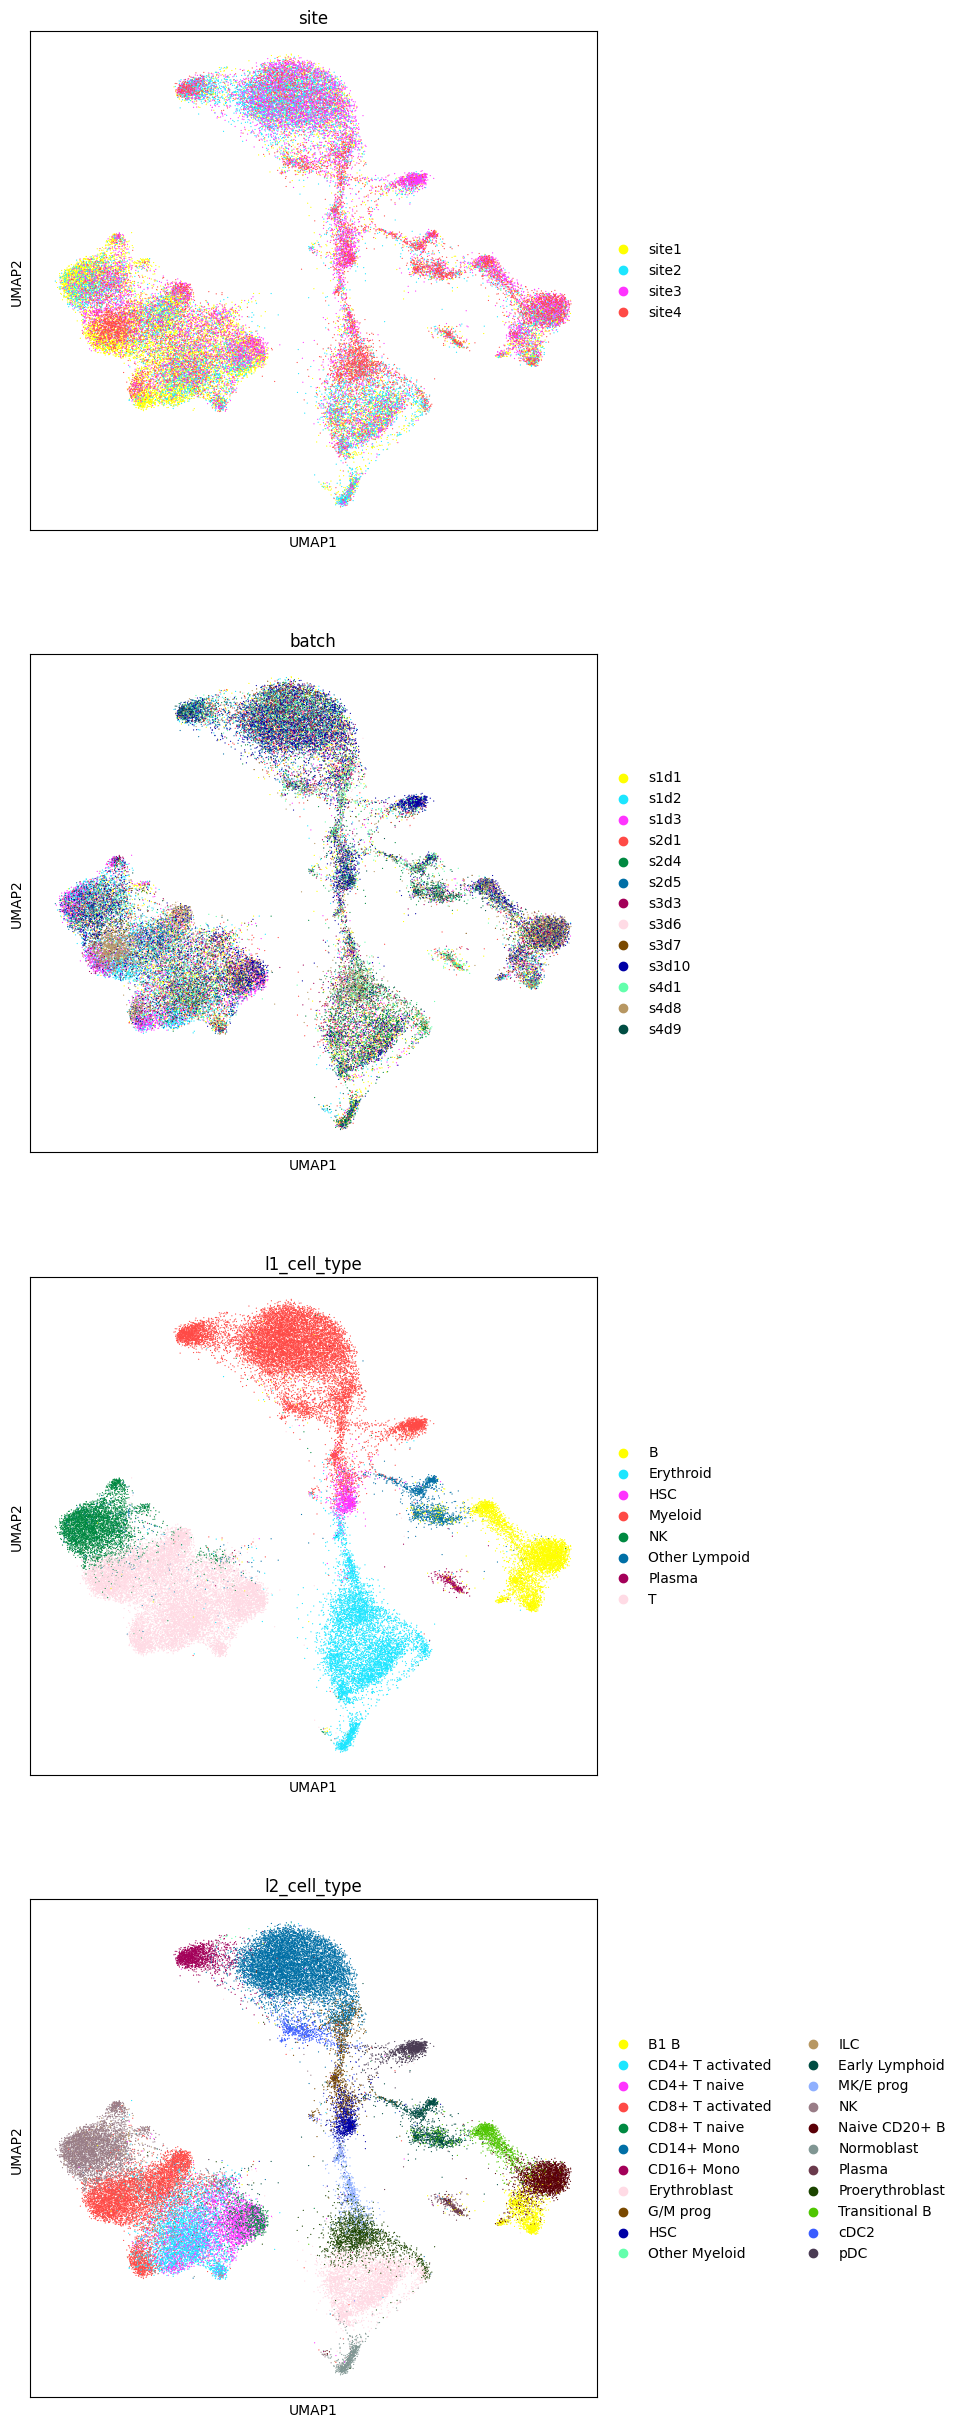

In [17]:
# UMAP coloured by batch, site, and cell type annotations
color = ["site", "batch", "l1_cell_type", "l2_cell_type"]

rcParams["figure.figsize"] = 7, 7
sc.pl.umap(
    adata,
    color=color,
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=3,
    vmin=0,
    vmax="p99.9",
    gene_symbols="SYMBOL",
    use_raw=False,
    legend_fontsize=10,
)

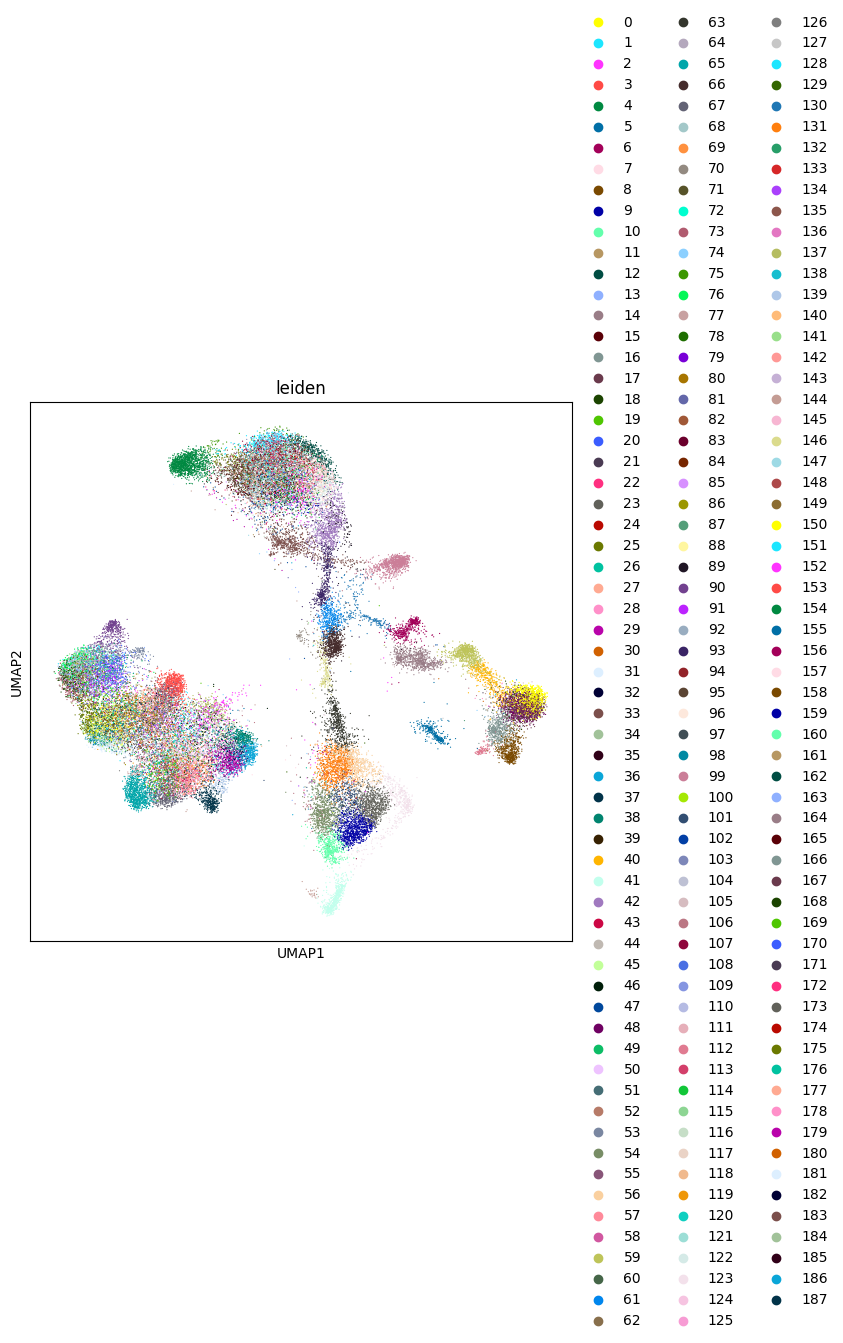

In [18]:
# Leiden clusters
rcParams["figure.figsize"] = 7, 7
sc.pl.umap(
    adata,
    color="leiden",
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=3,
    legend_fontsize=10,
)

## 6. Marker gene visualisation

Normalise marker genes per cell (counts per 10k) and overlay on UMAP to verify that the latent space captures expected biology.

In [ ]:
# Load comprehensive marker gene list
marker_df = pd.read_csv("known_marker_genes.csv")

# Get unique genes per category (preserving order)
categories = marker_df.groupby("category", sort=False)["gene"].apply(lambda x: list(dict.fromkeys(x)))

rcParams["figure.figsize"] = 6, 6

for category, gene_list in categories.items():
    # Filter to genes present in the data
    present = [g for g in gene_list if g in adata.var["SYMBOL"].values]
    if not present:
        continue

    # Normalise: counts per 10k
    gene_idx = adata.var["SYMBOL"].isin(present)
    selected_expr = adata[:, gene_idx].X.multiply(1.0 / adata.obs[["GEX_n_counts"]].values)
    selected_expr = selected_expr.toarray() * 1e4

    col_names = [f"{m} normalised" for m in present]
    adata.obs[col_names] = selected_expr

    print(f"\n{'=' * 60}")
    print(f"{category} ({len(present)} genes)")
    print(f"{'=' * 60}")

    sc.pl.umap(
        adata,
        color=col_names,
        color_map="RdPu",
        ncols=5,
        size=3,
        vmin=0,
        vmax="p99.99",
        gene_symbols="SYMBOL",
        use_raw=False,
        legend_fontsize=8,
        title=[f"{m}" for m in present],
    )

## 7. Save outputs

In [20]:
output_dir = f"{ref_run_name}/outputs/"
os.makedirs(output_dir, exist_ok=True)

# Save latent representation
X_scVI = pd.DataFrame(
    adata.obsm["X_scVI"],
    index=adata.obs_names,
    columns=range(adata.obsm["X_scVI"].shape[1]),
)
X_scVI.to_csv(f"{output_dir}/X_scVI.csv")

# Save UMAP coordinates
X_umap = pd.DataFrame(
    adata.obsm["X_umap"],
    index=adata.obs_names,
    columns=range(2),
)
X_umap.to_csv(f"{output_dir}/X_umap_k{k}.csv")

# Save leiden clustering
adata.obs[["leiden"]].to_csv(f"{output_dir}/leiden_k{k}.csv")

# Save KNN graph
scipy.sparse.save_npz(
    f"{output_dir}/distances_euclidean_k{k}.npz",
    adata.obsp["distances"],
    compressed=True,
)
scipy.sparse.save_npz(
    f"{output_dir}/connectivities_euclidean_k{k}.npz",
    adata.obsp["connectivities"],
    compressed=True,
)

print(f"Outputs saved to {output_dir}")

Outputs saved to results/regularizedvi_tutorial//model/outputs/


## Summary

This notebook used `AmbientRegularizedSCVI` with `likelihood_distribution="gamma_poisson"` — the cell2location-style dispersion prior direction. Compare the UMAP and marker gene plots with the other notebooks to assess the effect of the prior direction on integration quality.